# Neural Network and Embedding-Feature Rating Models

Rating prediction with collaborative models that learn from user and course ids only:

- **Neural networks:** NN1 is matrix factorisation (user and course embeddings with a dot product and biases). NN2 adds
  dense layers, dropout and larger embeddings.
- **Embedding-feature models:** the user and course embeddings learned by NN1 become features for regression models
  (linear, regularised, random forest, gradient boosting, XGBoost, LightGBM, linear SVR) and classification models.

All models are scored by test RMSE on the shared 80/20 rating split, on the original 3 to 5 rating scale, against the
global mean baseline. These models use no course content, so they are collaborative filtering models. The models that
combine collaborative and content signals are in `hybrid_recommenders.ipynb`.

In [1]:
%matplotlib inline

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeClassifier
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier, XGBRegressor

sys.path.append("..")
from recsys import data, metrics, results, splits

keras.utils.set_random_seed(splits.SEED)

## Data and split
The shared 80/20 rating split. 10% of the training set is held out as a validation set for early stopping.
The test set is only used for the final scores.

In [2]:
ratings = data.load_ratings()
index = data.Index(ratings)
train, test = splits.rating_split(ratings)
fit, val = train_test_split(train, test_size=0.1, random_state=splits.SEED)

RATING_RANGE = data.RATING_MAX - data.RATING_MIN


def to_inputs(df):
    return np.column_stack(index.encode(df))


def scale(rating):
    return (np.asarray(rating, dtype="float32") - data.RATING_MIN) / RATING_RANGE


def unscale(prediction):
    return np.clip(np.ravel(prediction), 0.0, 1.0) * RATING_RANGE + data.RATING_MIN


x_fit, y_fit = to_inputs(fit), scale(fit["rating"])
x_val, y_val = to_inputs(val), scale(val["rating"])
x_test = to_inputs(test)

baseline_rmse = metrics.rmse(test["rating"], train["rating"].mean())
print(f"Fit: {len(fit):,} | validation: {len(val):,} | test: {len(test):,}")
print(f"Global mean baseline test RMSE: {baseline_rmse:.4f}")

Fit: 167,979 | validation: 18,665 | test: 46,662
Global mean baseline test RMSE: 0.8123


## Neural networks
Ratings are scaled to [0, 1] for training. Every RMSE below is converted back to the 3 to 5 rating scale.
The original version of this analysis (then in `hybrid_recommenders.ipynb`) reported RMSE on the [0, 1] scale, which halves it and made the networks look
twice as accurate as models evaluated on the rating scale.

**NN1** is a matrix factorisation network: a user embedding dotted with a course embedding, plus a bias per user and
per course. The original version computed the dot product with `tf.tensordot(u, v, 2)`, which sums over the whole batch
and returns one number shared by every row. It now uses a per-row dot product.

In [3]:
class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_items, embedding_size=16, **kwargs):
        super().__init__(**kwargs)
        regularizer = keras.regularizers.l2(1e-6)
        self.user_embedding = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal",
            embeddings_regularizer=regularizer, name="user_embedding",
        )
        self.item_embedding = layers.Embedding(
            num_items, embedding_size, embeddings_initializer="he_normal",
            embeddings_regularizer=regularizer, name="item_embedding",
        )
        self.user_bias = layers.Embedding(num_users, 1, name="user_bias")
        self.item_bias = layers.Embedding(num_items, 1, name="item_bias")

    def call(self, inputs):
        users, items = inputs[:, 0], inputs[:, 1]
        dot = tf.reduce_sum(self.user_embedding(users) * self.item_embedding(items), axis=1, keepdims=True)
        return tf.nn.relu(dot + self.user_bias(users) + self.item_bias(items))

**NN2** adds larger embeddings, two dense hidden layers on the concatenated embeddings, dropout and a global bias.

In [4]:
class ImprovedRecommenderNet(keras.Model):
    def __init__(self, num_users, num_items, embedding_size=64, hidden_layers=(64, 32),
                 dropout_rate=0.5, l2_factor=1e-5, **kwargs):
        super().__init__(**kwargs)
        regularizer = keras.regularizers.l2(l2_factor)
        self.user_embedding = layers.Embedding(
            num_users, embedding_size, embeddings_initializer="he_normal",
            embeddings_regularizer=regularizer, name="user_embedding",
        )
        self.item_embedding = layers.Embedding(
            num_items, embedding_size, embeddings_initializer="he_normal",
            embeddings_regularizer=regularizer, name="item_embedding",
        )
        self.user_bias = layers.Embedding(num_users, 1, embeddings_initializer="zeros", name="user_bias")
        self.item_bias = layers.Embedding(num_items, 1, embeddings_initializer="zeros", name="item_bias")
        self.global_bias = self.add_weight(shape=(), initializer="zeros", name="global_bias")
        self.dropout = layers.Dropout(dropout_rate)
        self.hidden = [layers.Dense(units, activation="relu", kernel_regularizer=regularizer) for units in hidden_layers]
        self.output_layer = layers.Dense(1)

    def call(self, inputs, training=False):
        users, items = inputs[:, 0], inputs[:, 1]
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)
        dot = tf.reduce_sum(user_vec * item_vec, axis=1, keepdims=True)

        x = self.dropout(tf.concat([user_vec, item_vec], axis=1), training=training)
        for layer in self.hidden:
            x = self.dropout(layer(x), training=training)

        prediction = self.output_layer(x) + dot + self.user_bias(users) + self.item_bias(items) + self.global_bias
        return tf.nn.relu(prediction)

## Training
Both networks train with early stopping on validation RMSE and keep the best epoch's weights.

In [5]:
def train_network(model, epochs=30):
    model.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    early_stopping = keras.callbacks.EarlyStopping(monitor="val_rmse", patience=3, restore_best_weights=True)
    history = model.fit(
        x_fit, y_fit, batch_size=64, epochs=epochs,
        validation_data=(x_val, y_val), callbacks=[early_stopping], verbose=0,
    )
    train_rmse = np.array(history.history["rmse"]) * RATING_RANGE
    val_rmse = np.array(history.history["val_rmse"]) * RATING_RANGE
    best = int(np.argmin(val_rmse))
    print(f"{model.name}: {model.count_params():,} parameters, {len(val_rmse)} epochs, best epoch {best + 1}")
    print(f"  train RMSE {train_rmse[best]:.4f} | validation RMSE {val_rmse[best]:.4f} (rating scale)")
    return train_rmse, val_rmse


nn1 = RecommenderNet(index.n_users, index.n_items, embedding_size=16, name="NN1")
nn2 = ImprovedRecommenderNet(index.n_users, index.n_items, name="NN2")
curves = {"NN1": train_network(nn1), "NN2": train_network(nn2)}

NN1: 578,459 parameters, 4 epochs, best epoch 1
  train RMSE 0.8875 | validation RMSE 0.8277 (rating scale)


NN2: 2,222,125 parameters, 4 epochs, best epoch 1
  train RMSE 0.8322 | validation RMSE 0.8249 (rating scale)


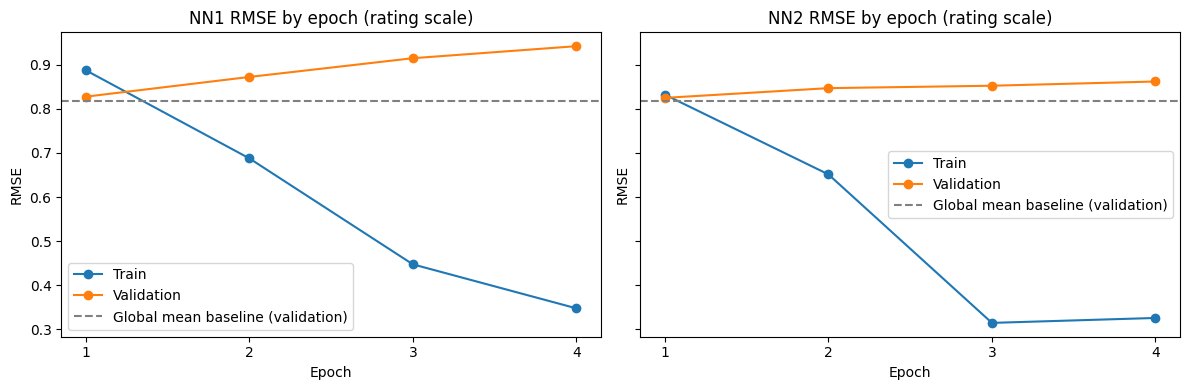

In [6]:
val_baseline = metrics.rmse(val["rating"], fit["rating"].mean())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, (train_rmse, val_rmse)) in zip(axes, curves.items()):
    epochs = np.arange(1, len(train_rmse) + 1)
    ax.plot(epochs, train_rmse, marker="o", label="Train")
    ax.plot(epochs, val_rmse, marker="o", label="Validation")
    ax.axhline(val_baseline, color="grey", linestyle="--", label="Global mean baseline (validation)")
    ax.set_title(f"{name} RMSE by epoch (rating scale)")
    ax.set_xlabel("Epoch")
    ax.set_xticks(epochs)
    ax.set_ylabel("RMSE")
    ax.legend()
plt.tight_layout()
plt.show()

Training RMSE falls quickly while validation RMSE never drops below the baseline: the networks memorise the training
ratings but find nothing that generalises.

In [7]:
rating_rows = []
for model in (nn1, nn2):
    prediction = unscale(model.predict(x_test, batch_size=4096, verbose=0))
    test_rmse = metrics.rmse(test["rating"], prediction)
    rating_rows.append({"family": "Neural network", "model": model.name, "test_rmse": test_rmse})
    print(f"{model.name} test RMSE: {test_rmse:.4f} (baseline {baseline_rmse:.4f})")

NN1 test RMSE: 0.8201 (baseline 0.8123)
NN2 test RMSE: 0.8173 (baseline 0.8123)


## Embedding features
The regression and classification models use the user and course embeddings learned by NN1 on the training data.
The original version used pre-computed embeddings downloaded from the course, which were trained on unknown data that
may have included the test ratings. It also added the user and course vectors together, which hides their interaction.
Here the features are the user vector, the course vector and their element-wise product.

This is a two-stage (stacked) model, so the second stage must be trained on rows the first stage never fitted.
For a row NN1 was trained on, the embeddings already encode that row's rating, and a model trained on those rows learns
to read the rating back out: an earlier run of this notebook that did so reached a cross-validation RMSE of 0.59 but a
test RMSE of 0.88. The regression and classification models are therefore trained on the validation rows, which NN1
only used for early stopping, and scored on the test set as before.

In [8]:
user_vectors = nn1.user_embedding.get_weights()[0]
item_vectors = nn1.item_embedding.get_weights()[0]


def embedding_features(df):
    users, items = index.encode(df)
    u, c = user_vectors[users], item_vectors[items]
    return np.hstack([u, c, u * c])


X_train, y_train = embedding_features(val), val["rating"].to_numpy()
X_test, y_test = embedding_features(test), test["rating"].to_numpy()
print(f"Second-stage training rows (NN1 validation set): {X_train.shape[0]:,} x {X_train.shape[1]} features")
print(f"Test rows: {X_test.shape[0]:,}")

Second-stage training rows (NN1 validation set): 18,665 x 48 features
Test rows: 46,662


## Regression models
Hyperparameters are tuned by 3-fold cross-validation on the second-stage training rows. Features are standardised
inside each pipeline, so the scaler only sees training folds. Linear SVR replaces kernel SVR with a linear kernel: it is the same
model class and scales to this many rows. XGBoost and LightGBM are included alongside scikit-learn's gradient boosting.

In [9]:
regression_models = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"ridge__alpha": [0.1, 1.0, 10.0, 100.0]}),
    "Lasso": (Lasso(), {"lasso__alpha": [0.001, 0.01, 0.1]}),
    "ElasticNet": (ElasticNet(), {"elasticnet__alpha": [0.01, 0.1], "elasticnet__l1_ratio": [0.2, 0.5, 0.8]}),
    "Random Forest": (RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5,
                                            n_jobs=-1, random_state=splits.SEED), {}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=splits.SEED),
                          {"gradientboostingregressor__learning_rate": [0.05, 0.1]}),
    "XGBoost": (XGBRegressor(n_estimators=300, max_depth=6, n_jobs=1, random_state=splits.SEED),
                {"xgbregressor__learning_rate": [0.05, 0.1]}),
    "LightGBM": (LGBMRegressor(n_estimators=300, num_leaves=31, n_jobs=1, verbose=-1, random_state=splits.SEED),
                 {"lgbmregressor__learning_rate": [0.05, 0.1]}),
    "Linear SVR": (LinearSVR(loss="squared_epsilon_insensitive", dual=False, random_state=splits.SEED), {"linearsvr__C": [0.01, 0.1, 1.0]}),
}

for name, (estimator, grid) in regression_models.items():
    pipeline = make_pipeline(StandardScaler(), estimator)
    search = GridSearchCV(pipeline, grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
    search.fit(X_train, y_train)
    test_rmse = metrics.rmse(y_test, search.predict(X_test))
    rating_rows.append({"family": "Embedding regression", "model": name, "test_rmse": test_rmse})
    params = {k.split("__")[1]: v for k, v in search.best_params_.items()}
    print(f"{name:<18} CV RMSE {-search.best_score_:.4f} | test RMSE {test_rmse:.4f} | {params}")

Linear Regression  CV RMSE 0.8206 | test RMSE 0.8134 | {}


Ridge              CV RMSE 0.8205 | test RMSE 0.8134 | {'alpha': 100.0}


Lasso              CV RMSE 0.8188 | test RMSE 0.8123 | {'alpha': 0.1}


ElasticNet         CV RMSE 0.8188 | test RMSE 0.8123 | {'alpha': 0.1, 'l1_ratio': 0.2}


Random Forest      CV RMSE 0.8211 | test RMSE 0.8135 | {}


Gradient Boosting  CV RMSE 0.8207 | test RMSE 0.8134 | {'learning_rate': 0.05}


XGBoost            CV RMSE 0.8380 | test RMSE 0.8254 | {'learning_rate': 0.05}


LightGBM           CV RMSE 0.8319 | test RMSE 0.8213 | {'learning_rate': 0.05}


Linear SVR         CV RMSE 0.8206 | test RMSE 0.8134 | {'C': 0.1}


## Classification models
Each rating is treated as one of three classes. Predicted classes are mapped back to ratings to compute RMSE on the same
scale as every other model. With three equally common classes, chance accuracy is about 33%.

In [10]:
label_encoder = LabelEncoder().fit(y_train)
classes_train = label_encoder.transform(y_train)

classification_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"logisticregression__C": [0.1, 1.0, 10.0]}),
    "Decision Tree": (DecisionTreeClassifier(max_depth=20, random_state=splits.SEED),
                      {"decisiontreeclassifier__min_samples_split": [2, 50]}),
    "Random Forest": (RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                                             n_jobs=-1, random_state=splits.SEED), {}),
    "Bagging": (BaggingClassifier(n_estimators=20, n_jobs=-1, random_state=splits.SEED),
                {"baggingclassifier__max_samples": [0.7, 1.0]}),
    "AdaBoost": (AdaBoostClassifier(n_estimators=100, random_state=splits.SEED),
                 {"adaboostclassifier__learning_rate": [0.1, 1.0]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=splits.SEED), {}),
    "XGBoost": (XGBClassifier(n_estimators=300, max_depth=6, n_jobs=1, random_state=splits.SEED),
                {"xgbclassifier__learning_rate": [0.05, 0.1]}),
    "LightGBM": (LGBMClassifier(n_estimators=300, num_leaves=31, n_jobs=1, verbose=-1, random_state=splits.SEED),
                 {"lgbmclassifier__learning_rate": [0.05, 0.1]}),
}

for name, (estimator, grid) in classification_models.items():
    pipeline = make_pipeline(StandardScaler(), estimator)
    search = GridSearchCV(pipeline, grid, cv=3, scoring="accuracy", n_jobs=-1)
    search.fit(X_train, classes_train)
    predicted_rating = label_encoder.inverse_transform(search.predict(X_test))
    test_rmse = metrics.rmse(y_test, predicted_rating)
    accuracy = accuracy_score(y_test, predicted_rating)
    rating_rows.append({"family": "Embedding classification", "model": name, "test_rmse": test_rmse})
    print(f"{name:<20} test accuracy {accuracy:.3f} | test RMSE {test_rmse:.4f}")

Logistic Regression  test accuracy 0.331 | test RMSE 1.1743


Decision Tree        test accuracy 0.332 | test RMSE 1.1790


Random Forest        test accuracy 0.330 | test RMSE 1.1852


Bagging              test accuracy 0.331 | test RMSE 1.1591


AdaBoost             test accuracy 0.331 | test RMSE 1.2868


Gradient Boosting    test accuracy 0.332 | test RMSE 1.1714


XGBoost              test accuracy 0.333 | test RMSE 1.1574


LightGBM             test accuracy 0.335 | test RMSE 1.1563


## Results

In [11]:
summary = pd.DataFrame(rating_rows)
summary["vs_baseline"] = (summary["test_rmse"] - baseline_rmse).round(4) + 0.0
summary.sort_values("test_rmse").round(4)

,family,model,test_rmse,vs_baseline
4,Embedding regression,Lasso,0.8123,0.0000
5,Embedding regression,ElasticNet,0.8123,0.0000
3,Embedding regression,Ridge,0.8134,0.0010
10,Embedding regression,Linear SVR,0.8134,0.0011
2,Embedding regression,Linear Regression,0.8134,0.0011
7,Embedding regression,Gradient Boosting,0.8134,0.0011
6,Embedding regression,Random Forest,0.8135,0.0011
1,Neural network,NN2,0.8173,0.0050
0,Neural network,NN1,0.8201,0.0077
9,Embedding regression,LightGBM,0.8213,0.0089


No model does better than the global mean baseline. The best, Lasso and ElasticNet, tie with it to four decimal places
because their regularisation shrinks every coefficient to zero, so they simply predict the mean. The classifiers are at
chance accuracy. On this dataset the ratings carry no learnable signal (see `model_comparison.ipynb`), so a better
architecture cannot help. The original result, where
the neural networks scored 0.43 against 0.81 for regression, came from comparing RMSE on a [0, 1] scale with RMSE on
the rating scale.

In [12]:
results.save(rating_rows, "rating_rmse", source="neural_embedding_models");